# Bank Marketing

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv(r'E:\DATA IS FUTURE\Python\Bank\Bank.csv', sep=';')

In [11]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [12]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 45211
Columns: 17


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [14]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [15]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

### Target Variable Distribution

The “no” category dominates with roughly 40,000+ observations.

The “yes” category has only about 5,000+, meaning only ~11% of customers subscribed to a term deposit.

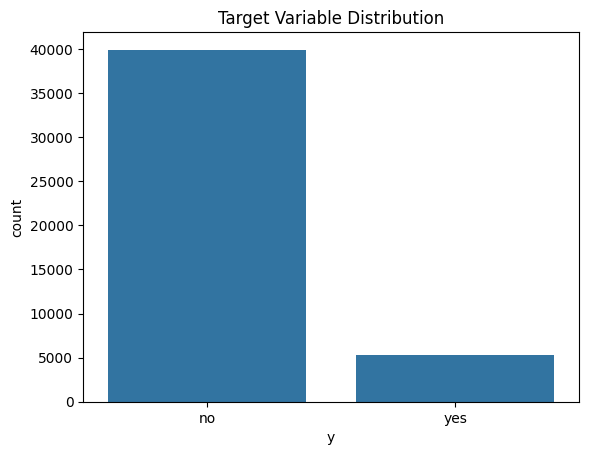

In [16]:
sns.countplot(x='y', data=df)
plt.title("Target Variable Distribution")
plt.show()

### Numerical Features Analysis



#### Age distribution
Most clients are between 30 and 50 years old, with fewer older customers.

This suggests the campaign primarily reached working-age adults.

#### Balance distribution
Highly right-skewed — most balances cluster near zero, but a few clients have very high balances.

#### Day distribution
Fairly uniform, with slight peaks around days 10, 20, and 30.

This could reflect periodic campaign scheduling or call patterns.

#### Duration distribution
Strongly right-skewed — most calls are short, but some last much longer.

Duration often correlates with success (y = yes), so it’s a key predictive feature.

#### Campaign distribution
Most clients were contacted only a few times (1–3).

A small number received many calls, which could indicate diminishing returns from repeated contact.

#### Pdays distribution
Almost all values are 0, meaning most clients hadn’t been contacted before.

A few outliers show follow-ups after long gaps (hundreds of days).

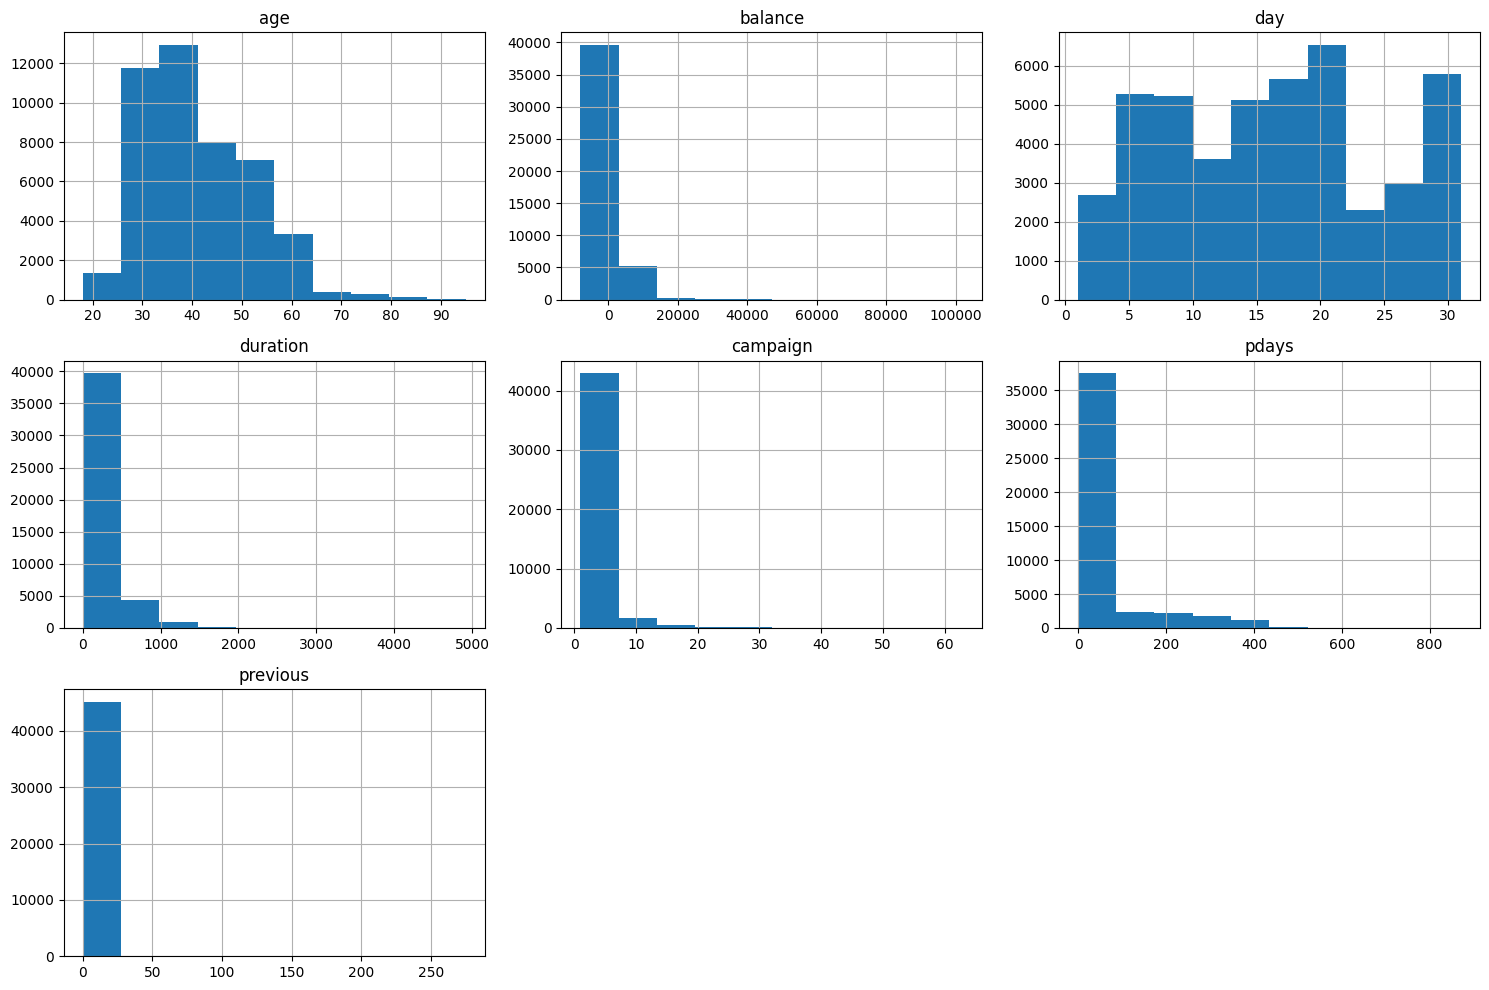

In [18]:
num_cols= df.select_dtypes(include=['int64','float64']).columns
df[num_cols].hist(figsize=(15,10))
plt.tight_layout()

## Correlation Heatmap

#### Strongest relationships
### pdays vs previous → 0.45  
Clients contacted previously tend to have non-zero pdays values — logical, since both measure prior campaign activity.

### day vs campaign → 0.16  
Slight positive correlation, possibly reflecting campaign timing patterns.

####  Weak or negligible correlations
age, balance, duration, campaign show almost no linear relationship with each other.

This suggests each variable captures distinct aspects of customer behaviour.

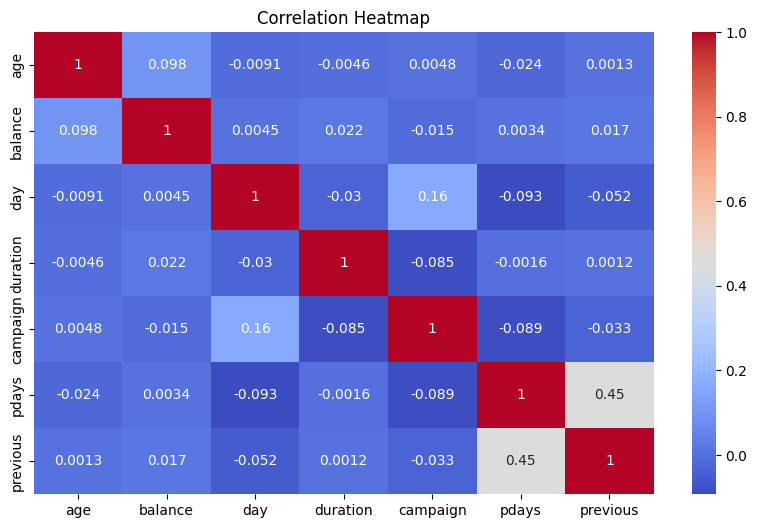

In [31]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

## Age Distribution
The distribution is right-skewed, peaking around 30–35 years.

Most clients fall between 25 and 55, with a gradual decline toward older ages.

Very few customers are above 70, suggesting the campaign mainly targeted working-age adults.

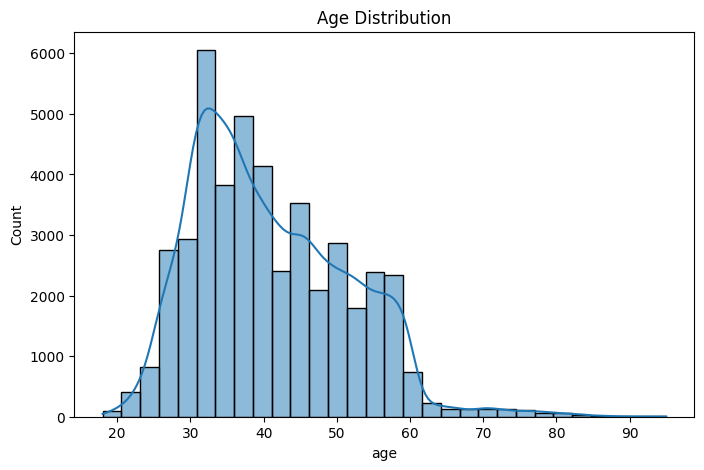

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=30, kde=True)

plt.title("Age Distribution")
plt.show()

## Job vs Subscription

#### Subscription trends by occupation
Retired and students show relatively higher proportions of “yes” responses compared to their total counts — these groups may be more receptive to term deposits.

Blue-collar and entrepreneur roles have the lowest subscription rates, possibly due to variable income or risk preferences.

#### Interpretation for marketing strategy
The bank could focus campaigns on retired and student segments, tailoring messages around stability and savings growth.

For working professionals, personalized offers or flexible deposit terms might improve conversion.

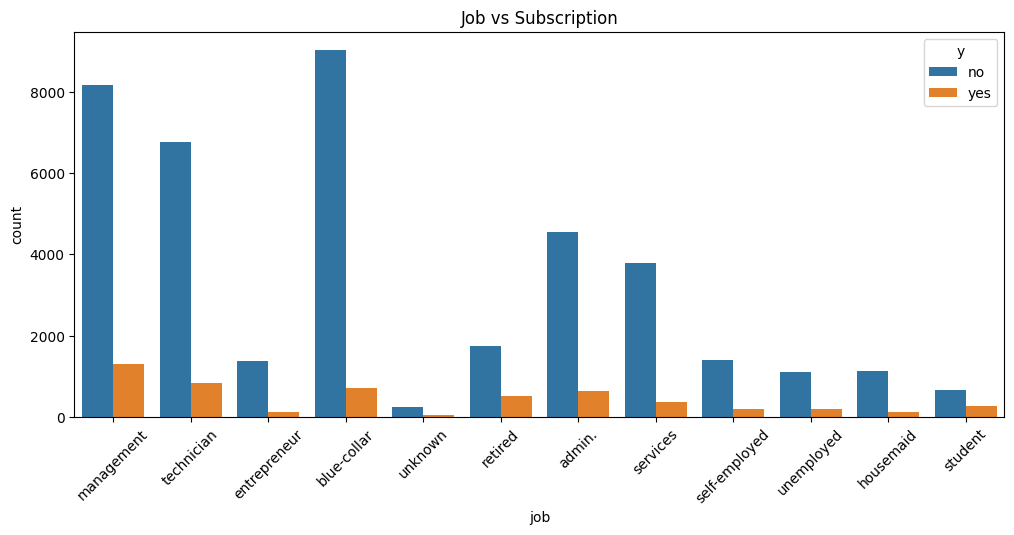

In [30]:
plt.figure(figsize=(12,5))
sns.countplot(
    x='job',
    hue='y',
    data=df
)
plt.xticks(rotation=45)
plt.title("Job vs Subscription")
plt.show()

## Education vs Subscription
#### Subscription trends by education
Clients with tertiary education show a slightly higher proportion of “yes” responses compared to other groups.

Those with primary education have the lowest subscription rate, suggesting education may correlate with financial awareness or trust in investment products.

#### Interpretation for marketing strategy
The bank could tailor campaigns emphasizing financial literacy for less-educated segments.

For tertiary-educated clients, focus on return rates and portfolio diversification — they’re more likely to respond to data-driven offers.

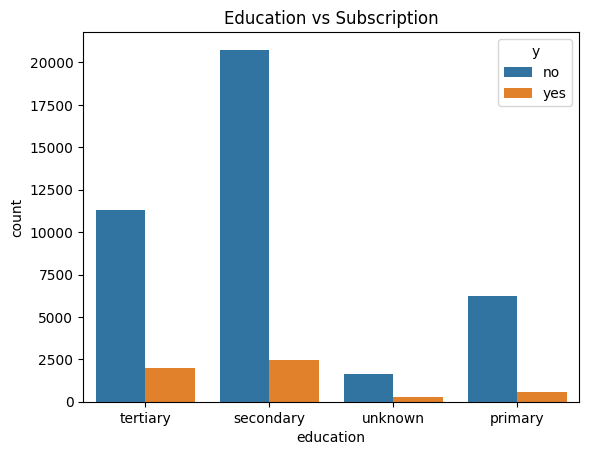

In [32]:
sns.countplot(
    x='education',
    hue='y',
    data=df
)

plt.title("Education vs Subscription")
plt.show()

## Marital Status vs Subscription

#### Interpretation for marketing strategy
The bank could tailor outreach differently:

Singles: emphasize independence and future planning.

Married: highlight family security and long-term savings.

Divorced: focus on rebuilding financial stability.

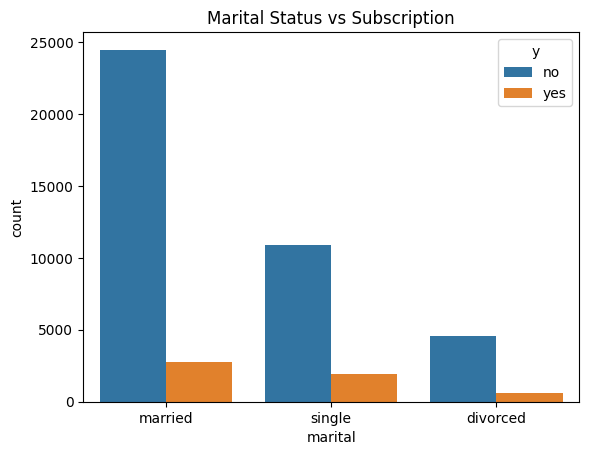

In [33]:
sns.countplot(
    x='marital',
    hue='y',
    data=df
)

plt.title("Marital Status vs Subscription")
plt.show()

### Balance Distribution
The boxplot shows a strong right skew, meaning most clients have balances close to zero, while a few have very high balances.

The dense cluster near zero indicates that many customers maintain low or moderate account balances.

Numerous outliers extend far to the right — some exceeding £100,000, suggesting a small group of high-value clients.

These outliers could represent wealthy individuals or corporate accounts.

The skewness implies that using raw balance values in modelling may distort results — consider log transformation or binning (e.g., low, medium, high balance categories).

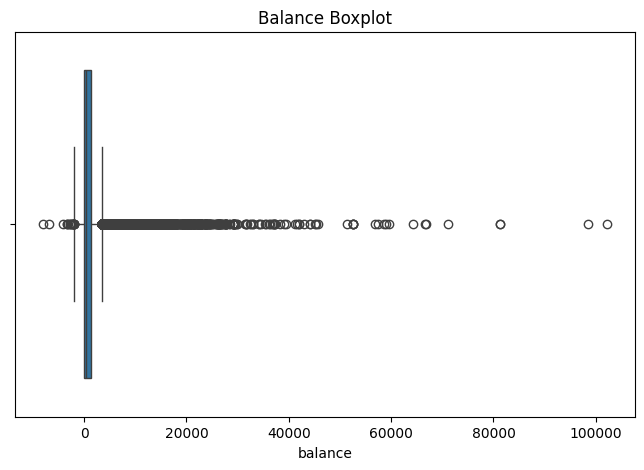

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['balance'])

plt.title("Balance Boxplot")
plt.show()

In [51]:


# Example: create 5 bins for balance
df['balance_bin'] = pd.cut(df['balance'], bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

# Or use quantile-based bins (equal-sized groups)
df['balance_quantile'] = pd.qcut(df['balance'], q=5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])


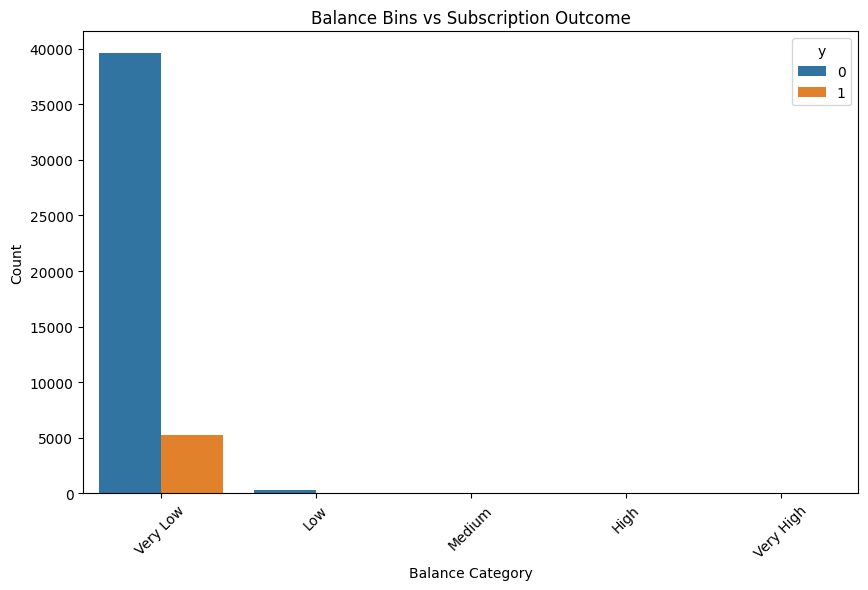

In [53]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='balance_bin', hue='y',
              order=df['balance_bin'].cat.categories)
plt.title('Balance Bins vs Subscription Outcome')
plt.xlabel('Balance Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


### Housing Loan Impact
The majority of clients have housing loans, as shown by the taller blue bar under “yes.”

Regardless of loan status, most customers did not subscribe to a term deposit (y = no).

However, clients without housing loans show a slightly higher proportion of “yes” responses — suggesting they may have more disposable income or financial flexibility.

#### Interpretation
Having a housing loan might reduce the likelihood of subscribing to a term deposit, possibly due to existing financial commitments.

Those without loans could be more open to investment products, as they have fewer liabilities.

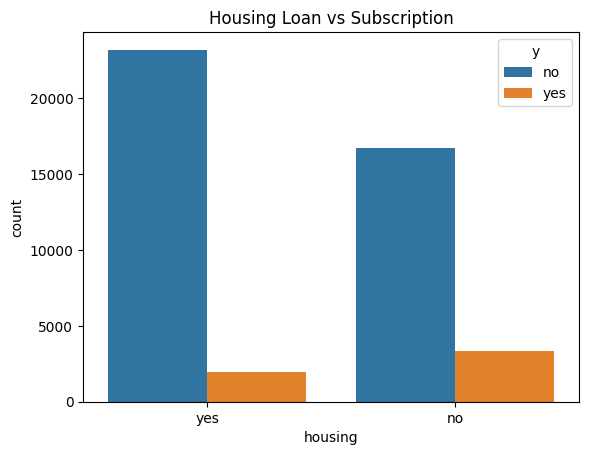

In [35]:
sns.countplot(
    x='housing',
    hue='y',
    data=df
)

plt.title("Housing Loan vs Subscription")
plt.show()

### Personal Loan Impact
Most clients do not have personal loans, as shown by the tall blue bar under “no.”

Among those without loans, the majority still did not subscribe to a term deposit (y = no).

Clients with loans show an even lower subscription rate — the orange “yes” bar is minimal.

#### Interpretation
Having a personal loan appears to negatively correlate with deposit subscription.

This makes sense: loan holders often prioritize debt repayment over new investments.

The absence of a loan may indicate financial stability, increasing the likelihood of subscribing.


The bank could target non-loan customers with term deposit offers emphasizing growth and savings.

For loan holders, campaigns might focus on debt management or combined loan-deposit benefits (e.g., interest offsets).

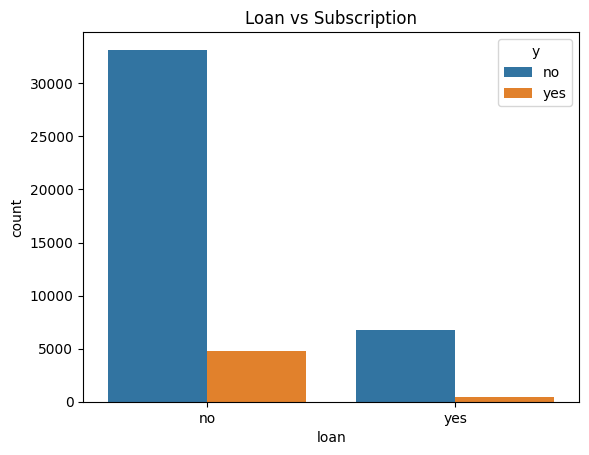

In [36]:
sns.countplot(
    x='loan',
    hue='y',
    data=df
)

plt.title("Loan vs Subscription")
plt.show()

### Campaign Analysis

The “no” group shows a wider spread and many outliers — some clients were contacted over 60 times without subscribing.

The “yes” group has fewer outliers and a lower median number of contacts, suggesting that successful subscriptions required fewer calls.

Excessive contact attempts may reduce effectiveness — customers might feel overwhelmed or uninterested after repeated calls.

Shorter, more targeted campaigns seem more successful, aligning with marketing efficiency principles.


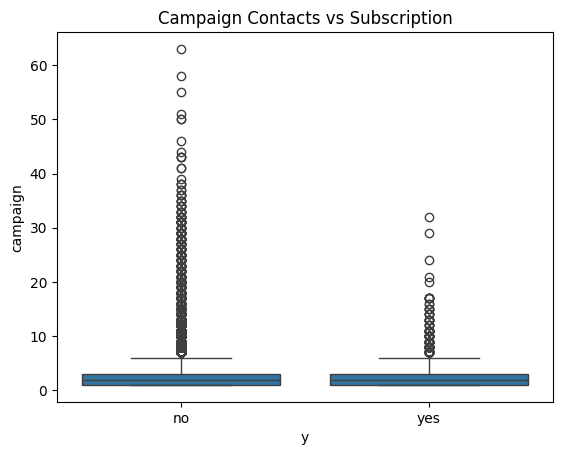

In [37]:
sns.boxplot(
    x='y',
    y='campaign',
    data=df
)

plt.title("Campaign Contacts vs Subscription")
plt.show()

### Duration Analysis
Longer calls likely indicate engaged conversations, where customers ask questions and consider offers.

Short calls often end before meaningful persuasion occurs.

This makes duration one of the strongest predictors of subscription success — possibly more influential than demographic or financial variables.
#### Strategy
The bank could use call duration thresholds to identify promising leads in real time.

For example, calls exceeding 2 minutes might trigger follow-up actions or personalized offers.

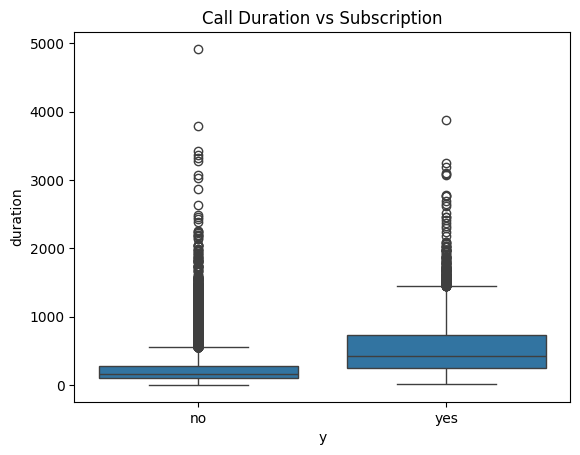

In [38]:
sns.boxplot(
    x='y',
    y='duration',
    data=df
)

plt.title("Call Duration vs Subscription")
plt.show()

### Subscription Percentage

In [41]:
target_percent = df['y'].value_counts(normalize=True) * 100

print(target_percent)

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


The bank’s campaign conversion rate is roughly 1 in 9.

Improving targeting (e.g., focusing on high-balance, retired, or tertiary-educated clients) could raise this percentage.

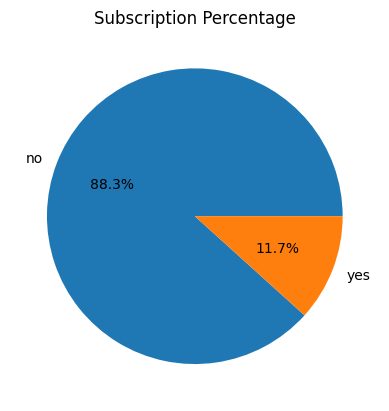

In [42]:
target_percent.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")
plt.title("Subscription Percentage")
plt.show()

### Data Preprocessing for Classification
#### Encode Target

In [43]:
df['y'] = df['y'].map({
    'no':0,
    'yes':1
})

#### Separate Features and Target

In [44]:
X = df.drop('y', axis=1)
y = df['y']

#### One-Hot Encoding

In [45]:
X = pd.get_dummies(
    X,
    drop_first=True
)

#### Train-Test Split

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Random Forest Classification

In [47]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [48]:
y_pred = model.predict(X_test)

In [49]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred
))

print(confusion_matrix(
    y_test,
    y_pred
))

Accuracy: 0.9058940617051864
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.67      0.39      0.49      1058

    accuracy                           0.91      9043
   macro avg       0.80      0.68      0.72      9043
weighted avg       0.89      0.91      0.89      9043

[[7778  207]
 [ 644  414]]


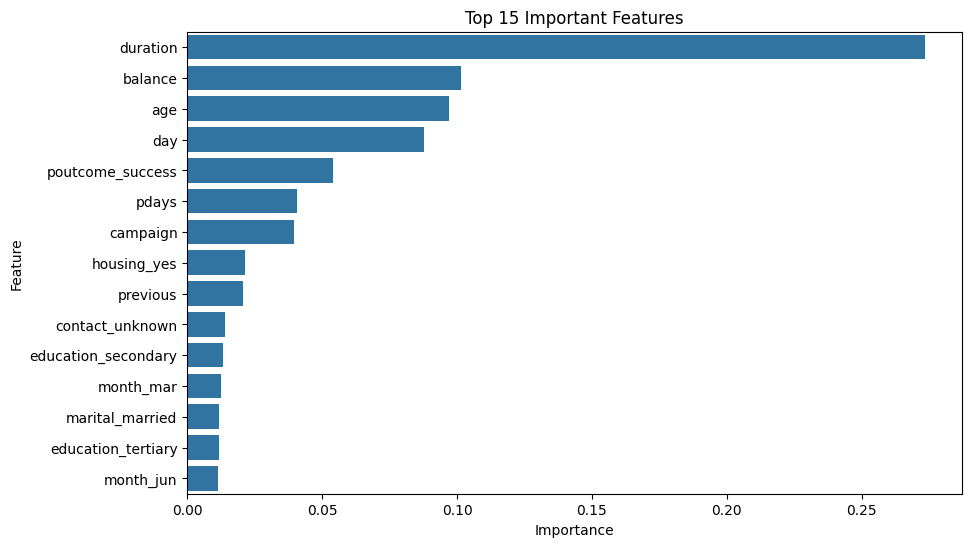

In [50]:

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(15)
)

plt.title("Top 15 Important Features")
plt.show()